# # Neutron Capture Event Structure Validation
# 
# **Tests:**
# 1. Event-ID ↔ (muon_id, nc_id) Tupel ändern sich bidirektional synchron
# 2. Gamma-Konsistenz: #Einträge = #unique gamma_ids = max(gamma_id)+1
# 3. Vertices-Konsistenz: DebugVertices vs. Geant4 vertices Output
# 4. Vollständigkeit: Alle event_ids vorhanden, gamma_ids lückenlos [0..N-1]

In [9]:
import h5py
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import glob
import os

In [20]:
# === Configuration ===
HDF5_DIR = "/home/tbueger/code/sim/RMGApplications/02-NCGammaGun/build/"  # Your HDF5 file path

# === Load Data ===
print("📂 Loading HDF5 data from multiple files...")

# Find all matching files
hdf5_files = sorted(glob.glob(os.path.join(HDF5_DIR, "output_t*.hdf5")))
if len(hdf5_files) == 0:
    raise FileNotFoundError(f"No output_t*.hdf5 files found in {HDF5_DIR}")

print(f"Found {len(hdf5_files)} files to process")

# Initialize lists to collect data
all_debug_event_id = []
all_debug_muon_id = []
all_debug_nc_id = []
all_debug_gamma_id = []
all_vertices_event_id = []
all_vertices_n_part = []

# Load from all files
for i, filepath in enumerate(hdf5_files):
    print(f"  Loading file {i+1}/{len(hdf5_files)}: {os.path.basename(filepath)}")
    
    with h5py.File(filepath, 'r') as f:
        # Load DebugVertices
        all_debug_event_id.append(f['//hit/DebugVertices/event_id/pages'][:])
        all_debug_muon_id.append(f['//hit/DebugVertices/muon_id/pages'][:])
        all_debug_nc_id.append(f['//hit/DebugVertices/nc_id/pages'][:])
        all_debug_gamma_id.append(f['//hit/DebugVertices/gamma_id/pages'][:])
        
        # Load Geant4 vertices
        all_vertices_event_id.append(f['//hit/vertices/evtid/pages'][:])
        all_vertices_n_part.append(f['//hit/vertices/n_part/pages'][:])

# Concatenate all arrays
debug_event_id = np.concatenate(all_debug_event_id)
debug_muon_id = np.concatenate(all_debug_muon_id)
debug_nc_id = np.concatenate(all_debug_nc_id)
debug_gamma_id = np.concatenate(all_debug_gamma_id)
vertices_event_id = np.concatenate(all_vertices_event_id)
vertices_n_part = np.concatenate(all_vertices_n_part)

# Create DataFrames
df_debug = pd.DataFrame({
    'event_id': debug_event_id,
    'muon_id': debug_muon_id,
    'nc_id': debug_nc_id,
    'gamma_id': debug_gamma_id
})

df_vertices = pd.DataFrame({
    'event_id': vertices_event_id,
    'n_part': vertices_n_part
})

print(f"✅ Loaded {len(df_debug)} DebugVertices entries")
print(f"✅ Loaded {len(df_vertices)} Geant4 vertices entries")
print()


📂 Loading HDF5 data from multiple files...
Found 4 files to process
  Loading file 1/4: output_t0.hdf5
  Loading file 2/4: output_t1.hdf5
  Loading file 3/4: output_t2.hdf5
  Loading file 4/4: output_t3.hdf5
✅ Loaded 1330 DebugVertices entries
✅ Loaded 1330 Geant4 vertices entries



In [ ]:
# === TEST 1: Event-ID ↔ (muon_id, nc_id) Bidirektionale Synchronisation ===
print("=" * 70)
print("TEST 1: Event-ID ↔ (muon_id, nc_id) Tupel Synchronisation")
print("=" * 70)

# Check: Event-ID wechselt ↔ (muon_id, nc_id) wechselt
df_debug['nc_tuple'] = list(zip(df_debug['muon_id'], df_debug['nc_id']))
df_debug['nc_tuple_changed'] = df_debug['nc_tuple'] != df_debug['nc_tuple'].shift(1)
df_debug['event_id_changed'] = df_debug['event_id'] != df_debug['event_id'].shift(1)

# Erste Zeile immer True (kein Vergleich möglich)
df_debug.loc[0, 'nc_tuple_changed'] = True
df_debug.loc[0, 'event_id_changed'] = True

# Bidirektionaler Check
violations_nc_but_not_event = df_debug[
    df_debug['nc_tuple_changed'] & ~df_debug['event_id_changed']
]
violations_event_but_not_nc = df_debug[
    df_debug['event_id_changed'] & ~df_debug['nc_tuple_changed']
]

test1_passed = len(violations_nc_but_not_event) == 0 and len(violations_event_but_not_nc) == 0

if test1_passed:
    print("✅ PASSED: Event-ID und NC-Tupel ändern sich synchron")
else:
    print("❌ FAILED: Inkonsistente Änderungen gefunden!")
    if len(violations_nc_but_not_event) > 0:
        print(f"   NC wechselt, aber Event-ID nicht: {len(violations_nc_but_not_event)} Fälle")
        print(violations_nc_but_not_event[['event_id', 'muon_id', 'nc_id', 'gamma_id']].head())
    if len(violations_event_but_not_nc) > 0:
        print(f"   Event-ID wechselt, aber NC nicht: {len(violations_event_but_not_nc)} Fälle")
        print(violations_event_but_not_nc[['event_id', 'muon_id', 'nc_id', 'gamma_id']].head())

print()


TEST 1: Event-ID ↔ (muon_id, nc_id) Tupel Synchronisation
✅ PASSED: Event-ID und NC-Tupel ändern sich synchron
   Unique (muon_id, nc_id) pairs: 279

📌 Gammas per Event:



In [17]:
# === TEST 2: Gamma-Konsistenz pro Event ===
print("=" * 70)
print("TEST 2: Gamma-Konsistenz (#Einträge = #unique gamma_ids = max+1)")
print("=" * 70)

gamma_stats = df_debug.groupby('event_id')['gamma_id'].agg([
    ('n_entries', 'size'),
    ('n_unique', 'nunique'),
    ('max_id', 'max'),
    ('min_id', 'min')
])
gamma_stats['max_plus_1'] = gamma_stats['max_id'] + 1

# Test A: n_entries == n_unique
test2a_violations = gamma_stats[gamma_stats['n_entries'] != gamma_stats['n_unique']]

# Test B: n_entries == max+1
test2b_violations = gamma_stats[gamma_stats['n_entries'] != gamma_stats['max_plus_1']]

# Test C: min_id == 0 (gamma_ids starten bei 0)
test2c_violations = gamma_stats[gamma_stats['min_id'] != 0]

test2_passed = (len(test2a_violations) == 0 and 
                len(test2b_violations) == 0 and 
                len(test2c_violations) == 0)

if test2_passed:
    print("✅ PASSED: Alle Events haben konsistente gamma_ids [0..N-1]")
    print(f"   Mean gammas/event: {gamma_stats['n_entries'].mean():.2f}")
    print(f"   Min: {gamma_stats['n_entries'].min()}, Max: {gamma_stats['n_entries'].max()}")
else:
    print("❌ FAILED: Inkonsistente gamma_ids gefunden!")
    if len(test2a_violations) > 0:
        print(f"   Duplikate oder fehlende gamma_ids: {len(test2a_violations)} Events")
        print(test2a_violations.head())
    if len(test2b_violations) > 0:
        print(f"   max(gamma_id)+1 ≠ Anzahl: {len(test2b_violations)} Events")
        print(test2b_violations.head())
    if len(test2c_violations) > 0:
        print(f"   gamma_id startet nicht bei 0: {len(test2c_violations)} Events")
        print(test2c_violations.head())

print()

TEST 2: Gamma-Konsistenz (#Einträge = #unique gamma_ids = max+1)
✅ PASSED: Alle Events haben konsistente gamma_ids [0..N-1]
   Mean gammas/event: 1.33
   Min: 1, Max: 6



In [13]:
# === TEST 3: DebugVertices vs. Geant4 vertices ===
print("=" * 70)
print("TEST 3: DebugVertices ↔ Geant4 vertices Konsistenz")
print("=" * 70)

# Count entries per event_id in both datasets
debug_counts = df_debug.groupby('event_id').size().reset_index(name='debug_count')
vertices_counts = df_vertices.groupby('event_id').size().reset_index(name='vertices_count')

# Merge
comparison = pd.merge(debug_counts, vertices_counts, on='event_id', how='outer')
comparison.fillna(0, inplace=True)
comparison = comparison.astype({'debug_count': int, 'vertices_count': int})

# Check mismatches
mismatches = comparison[comparison['debug_count'] != comparison['vertices_count']]

test3_passed = len(mismatches) == 0

if test3_passed:
    print("✅ PASSED: DebugVertices und Geant4 vertices haben gleiche Anzahl pro Event")
else:
    print("❌ FAILED: Unterschiedliche Anzahl gefunden!")
    print(f"   {len(mismatches)} Events mit Diskrepanz:")
    print(mismatches.head(10))

print()

TEST 3: DebugVertices ↔ Geant4 vertices Konsistenz
✅ PASSED: DebugVertices und Geant4 vertices haben gleiche Anzahl pro Event



In [22]:
# === TEST 4: Vollständigkeit ===
print("=" * 70)
print("TEST 4: Vollständigkeit (alle event_ids vorhanden)")
print("=" * 70)

# Expected event_ids: [0..max_event_id]
max_event_id = df_debug['event_id'].max()
expected_events = set(range(max_event_id + 1))
actual_events = set(df_debug['event_id'].unique())

missing_events = expected_events - actual_events
extra_events = actual_events - expected_events

test4_passed = len(missing_events) == 0 and len(extra_events) == 0

if test4_passed:
    print(f"✅ PASSED: Alle event_ids [0..{max_event_id}] vorhanden")
else:
    print("❌ FAILED: Fehlende oder zusätzliche event_ids!")
    if missing_events:
        print(f"   Fehlend: {sorted(missing_events)[:10]}{'...' if len(missing_events) > 10 else ''}")
    if extra_events:
        print(f"   Zusätzlich: {sorted(extra_events)[:10]}{'...' if len(extra_events) > 10 else ''}")


print(f"   Unique (muon_id, nc_id) pairs: {df_debug[['muon_id', 'nc_id']].drop_duplicates().shape[0]}")

print()

TEST 4: Vollständigkeit (alle event_ids vorhanden)
✅ PASSED: Alle event_ids [0..999] vorhanden
   Unique (muon_id, nc_id) pairs: 279



📊 FINAL SUMMARY
✅ PASS: Event-ID ↔ NC-Tupel Sync
✅ PASS: Gamma-ID Konsistenz
✅ PASS: DebugVertices ↔ Geant4 vertices
✅ PASS: Event-ID Vollständigkeit

🎉 ALL TESTS PASSED! Event structure is consistent.

📈 Generating plots...


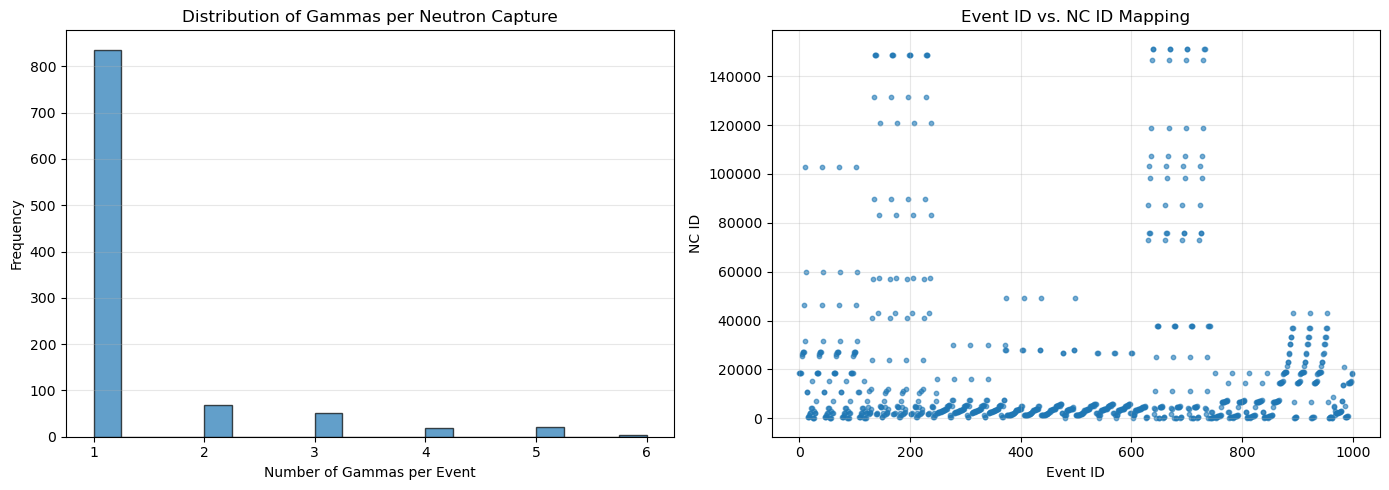

✅ Plots generated

📊 DETAILED STATISTICS

📌 Dataset Overview:
   Total events: 1000
   Total vertices (DebugVertices): 1330
   Total vertices (Geant4): 1330
   Unique muon_ids: 56
   Unique nc_ids: 278

📌 Gammas per Event:
   Mean: 1.33
   Std:  0.87
   Min:  1
   Max:  6

📌 NC-IDs per Muon:
   Mean NCs/muon: 4.98
   Min:  1
   Max:  48

✅ Debug script completed


In [15]:
# === SUMMARY ===
print("=" * 70)
print("📊 FINAL SUMMARY")
print("=" * 70)

all_passed = test1_passed and test2_passed and test3_passed and test4_passed

tests = [
    ("Event-ID ↔ NC-Tupel Sync", test1_passed),
    ("Gamma-ID Konsistenz", test2_passed),
    ("DebugVertices ↔ Geant4 vertices", test3_passed),
    ("Event-ID Vollständigkeit", test4_passed)
]

for name, passed in tests:
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"{status}: {name}")

print()
if all_passed:
    print("🎉 ALL TESTS PASSED! Event structure is consistent.")
else:
    print("⚠️  SOME TESTS FAILED! Review output above.")

# %%
# === VISUALIZATION: Gammas per Event ===
print("\n📈 Generating plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of gammas per event
axes[0].hist(gamma_stats['n_entries'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Gammas per Event')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Gammas per Neutron Capture')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Event-ID vs. NC-ID (should be 1:1)
event_nc_map = df_debug.groupby('event_id')['nc_id'].first().reset_index()
axes[1].scatter(event_nc_map['event_id'], event_nc_map['nc_id'], s=10, alpha=0.6)
axes[1].set_xlabel('Event ID')
axes[1].set_ylabel('NC ID')
axes[1].set_title('Event ID vs. NC ID Mapping')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Plots generated")

# %%
# === STATISTICS OUTPUT ===
print("\n" + "=" * 70)
print("📊 DETAILED STATISTICS")
print("=" * 70)

print(f"\n📌 Dataset Overview:")
print(f"   Total events: {df_debug['event_id'].nunique()}")
print(f"   Total vertices (DebugVertices): {len(df_debug)}")
print(f"   Total vertices (Geant4): {len(df_vertices)}")
print(f"   Unique muon_ids: {df_debug['muon_id'].nunique()}")
print(f"   Unique nc_ids: {df_debug['nc_id'].nunique()}")

print(f"\n📌 Gammas per Event:")
print(f"   Mean: {gamma_stats['n_entries'].mean():.2f}")
print(f"   Std:  {gamma_stats['n_entries'].std():.2f}")
print(f"   Min:  {gamma_stats['n_entries'].min()}")
print(f"   Max:  {gamma_stats['n_entries'].max()}")

print(f"\n📌 NC-IDs per Muon:")
ncs_per_muon = df_debug.groupby('muon_id')['nc_id'].nunique()
print(f"   Mean NCs/muon: {ncs_per_muon.mean():.2f}")
print(f"   Min:  {ncs_per_muon.min()}")
print(f"   Max:  {ncs_per_muon.max()}")

print("\n✅ Debug script completed")